# SLFNet — Sentinel-LISS IV Fusion Network

End-to-end experiment notebook for cloud removal on ISRO LISS-IV imagery. Runs the DiffCR diffusion branch through a progression of domain-adaptation stages (projection layer → conditioning-encoder transfer learning → full fine-tuning), then combines it with the UnCRtainTS-NAFNet SAR branch in the final multimodal fusion step. See the project [README](README.md) for the full architecture and results table.

In [ ]:
import subprocess, os

result = subprocess.run(['nvidia-smi', '--query-gpu=name,memory.total',
                         '--format=csv,noheader'], capture_output=True, text=True)
print('GPU:', result.stdout.strip() or 'No GPU — switch to T4 in Runtime > Change runtime type')

disk = subprocess.run(['df', '-h', '/'], capture_output=True, text=True)
print('Disk:\n', disk.stdout)

mem = subprocess.run(['free', '-h'], capture_output=True, text=True)
print('RAM:\n', mem.stdout)

GPU: Tesla T4, 15360 MiB
Disk:
 Filesystem      Size  Used Avail Use% Mounted on
overlay         113G   48G   66G  42% /

RAM:
                total        used        free      shared  buff/cache   available
Mem:            12Gi       737Mi       8.5Gi       2.0Mi       3.5Gi        11Gi
Swap:             0B          0B          0B



In [ ]:
!pip install -q kagglehub rasterio einops timm huggingface_hub
!pip install -q torch torchvision --extra-index-url https://download.pytorch.org/whl/cu118

In [ ]:
!pip install -q --force-reinstall numpy==1.26.4

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 94.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
shap 0.52.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
pytensor 2.38.3 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.

## Dataset Acquisition

Downloads the pre-processed LISS-IV + Sentinel-1 SAR scene archive (a Kaggle mirror of the Bhoonidhi-sourced data collected with `bhoonidhi_scraper.py`) and does a sanity read with `rasterio`.

In [ ]:
import os, json
from pathlib import Path

KAGGLE_JSON = Path('/root/.kaggle/kaggle.json')
KAGGLE_JSON.parent.mkdir(parents=True, exist_ok=True)

if not KAGGLE_JSON.exists():
    creds = {
        'username': 'your_kaggle_username',
        'key':      'your_kaggle_key'
    }
    KAGGLE_JSON.write_text(json.dumps(creds))
    KAGGLE_JSON.chmod(0o600)
    print('Credentials written from Option B.')
else:
    KAGGLE_JSON.chmod(0o600)
    print('kaggle.json already present ✓')

Credentials written from Option B.


In [ ]:
!kaggle datasets download ritwik8307/fable-6 --path /content/

import os
ZIP_PATH = '/content/fable-6.zip'
print(f"Exists : {os.path.exists(ZIP_PATH)}")
print(f"Size   : {os.path.getsize(ZIP_PATH)/1e9:.2f} GB")

Dataset URL: https://www.kaggle.com/datasets/ritwik8307/fable-6
License(s): MIT
100% 28.0G/28.0G [23:04<00:00, 21.7MB/s]

Exists : True
Size   : 30.06 GB


In [ ]:
import os, zipfile, rasterio
from rasterio.io import MemoryFile

print(f"Symlink: {ZIP_PATH}")

with rasterio.open(f'/vsizip/{ZIP_PATH}/ahemdabad_cloudy_1/BAND2.tif') as src:
    arr = src.read()
    print(arr.shape, arr.dtype, src.res)

Symlink: /content/fable-6.zip


(1, 16260, 18318) uint16 (5.0, 5.0)


In [ ]:
with rasterio.open(f'/vsizip/{ZIP_PATH}/ahemdabad_cloudy_1_sar.tif') as src:
    sar = src.read().astype('float32')
    print('SAR shape:', sar.shape)
    print('SAR range:', sar.min(), 'to', sar.max())

SAR shape: (1, 16260, 18318)
SAR range: -30.491428 to 27.839043


## Dataset Configuration & Preprocessing

Defines the per-city cloudy/clear-reference timestamp mapping, then the crop, normalization, and patching utilities shared by both model branches.

In [ ]:
CITIES = {
    'ahmedabad': {
        'cloudy': ['ahemdabad_cloudy_1', 'ahemdabad_cloudy_3', 'ahemdabad_cloudy_4',
                   'ahemdabad_cloudy_5', 'ahemdabad_cloudy_6'],
        'gt': 'ahemdabad_non_cloudy_2'
    },
    'hyderabad': {
        'cloudy': ['hyderabad_cloudy_2', 'hyderabad_cloudy_3', 'hyderabad_cloudy_4',
                   'hyderabad_cloudy_5', 'hyderabad_cloudy_6'],
        'gt': 'hyderabad_non_cloudy_1'
    },
    'pune': {
        'cloudy': ['pune_cloudy_2', 'pune_cloudy_3', 'pune_cloudy_6'],
        'gt': 'pune_non_cloudy_1'
    }
}
CITY = 'ahmedabad'
print(f"Working on: {CITY}")
print(f"  Cloudy timestamps : {CITIES[CITY]['cloudy']}")
print(f"  Ground truth      : {CITIES[CITY]['gt']}")

Working on: ahmedabad
  Cloudy timestamps : ['ahemdabad_cloudy_1', 'ahemdabad_cloudy_3', 'ahemdabad_cloudy_4', 'ahemdabad_cloudy_5', 'ahemdabad_cloudy_6']
  Ground truth      : ahemdabad_non_cloudy_2


In [ ]:
ZIP_PATH="fable-6.zip"

In [ ]:
import rasterio, numpy as np
from rasterio.windows import Window

H_FULL, W_FULL = 16260, 18318
CROP  = 2048
ROW0  = (H_FULL - CROP) // 2
COL0  = (W_FULL - CROP) // 2

def _win():
    return Window(COL0, ROW0, CROP, CROP)

def load_optical_crop(folder):
    bands = []
    for b in ['BAND2', 'BAND3', 'BAND4']:
        with rasterio.open(f'/vsizip/{ZIP_PATH}/{folder}/{b}.tif') as src:
            bands.append(src.read(1, window=_win()).astype(np.float32))
    return np.stack(bands, 0)

def load_sar_crop(folder):
    with rasterio.open(f'/vsizip/{ZIP_PATH}/{folder}_sar.tif') as src:
        return src.read(1, window=_win(), out_dtype=np.float32)[None]

_t = load_optical_crop(CITIES[CITY]['cloudy'][0])
_s = load_sar_crop(CITIES[CITY]['cloudy'][0])
print(f"Optical: {_t.shape}  range [{_t.min():.0f}, {_t.max():.0f}]")
print(f"SAR    : {_s.shape}  range [{_s.min():.2f}, {_s.max():.2f}] dB")
del _t, _s

Optical: (3, 2048, 2048)  range [116, 864]
SAR    : (1, 2048, 2048)  range [-22.85, 21.03] dB


In [ ]:
!pwd

/content


In [ ]:
import numpy as np

def norm_optical(arr):
    out = np.empty_like(arr, dtype=np.float32)
    for c in range(3):
        lo, hi = np.percentile(arr[c], [2, 98])
        out[c]  = np.clip((arr[c] - lo) / (hi - lo + 1e-6), 0., 1.)
    return out

SAR_LO, SAR_HI = -25.0, 5.0

def norm_sar(arr):
    return (np.clip(arr, SAR_LO, SAR_HI) - SAR_LO) / (SAR_HI - SAR_LO)

LISS4_TO_S2 = {0: 2, 1: 3, 2: 7}

def pad_to_s2(opt_3):
    s2 = np.zeros((13, *opt_3.shape[1:]), np.float32)
    for liss_idx, s2_idx in LISS4_TO_S2.items():
        s2[s2_idx] = opt_3[liss_idx]
    return s2

def pad_sar_to_2ch(sar_1):
    return np.concatenate([sar_1, sar_1], 0)

print("Norm functions ready.")
print(f"  S2 band positions used: {LISS4_TO_S2}")

Norm functions ready.
  S2 band positions used: {0: 2, 1: 3, 2: 7}


In [ ]:
import numpy as np

PATCH  = 512
STRIDE = 512

def patchify(arr):
    C, H, W = arr.shape
    patches, coords = [], []
    for r in range(0, H - PATCH + 1, STRIDE):
        for c in range(0, W - PATCH + 1, STRIDE):
            patches.append(arr[:, r:r+PATCH, c:c+PATCH].copy())
            coords.append((r, c))
    return patches, coords

def unpatchify(patches, coords, H=CROP, W=CROP):
    C = patches[0].shape[0]
    canvas = np.zeros((C, H, W), np.float32)
    count  = np.zeros((H, W),    np.float32)
    for p, (r, c) in zip(patches, coords):
        canvas[:, r:r+PATCH, c:c+PATCH] += p
        count [    r:r+PATCH, c:c+PATCH] += 1
    return canvas / np.maximum(count, 1)[None]

dummy = np.random.rand(3, CROP, CROP).astype(np.float32)
pats, cds = patchify(dummy)
rec  = unpatchify(pats, cds)
print(f"Patches  : {len(pats)} × {pats[0].shape}")
print(f"Max recon error : {np.abs(dummy - rec).max():.6f}  (should be 0)")
del dummy, pats, cds, rec

Patches  : 16 × (3, 512, 512)
Max recon error : 0.000000  (should be 0)


## DiffCR — Diffusion Cloud-Removal Branch

Clones DiffCR, loads the pretrained double-encoder checkpoint, and runs baseline inference by sliding a window of 3 timestamps across the 5 cloudy acquisitions.

In [ ]:
import sys, os

!git clone https://github.com/XavierJiezou/DiffCR /content/DiffCR
sys.path.insert(0, '/content/DiffCR')
print("Repos ready.")

Cloning into '/content/DiffCR'...
remote: Enumerating objects: 338, done.
remote: Counting objects: 100% (143/143), done.
remote: Compressing objects: 100% (63/63), done.
remote: Total 338 (delta 103), reused 82 (delta 80), pack-reused 195 (from 1)
Receiving objects: 100% (338/338), 197.81 MiB | 19.83 MiB/s, done.
Resolving deltas: 100% (147/147), done.
Updating files: 100% (128/128), done.
Repos ready.


In [ ]:
from huggingface_hub import hf_hub_download

REPO = "XavierJiezou/diffcr-models"

diffcr_ckpt = hf_hub_download(
    repo_id   = REPO,
    filename  = "experiments/train_nafnet_double_encoder_splitcaCond_splitcaUnet_sigmoid_noisen3_230611_035949/checkpoint/3000_Network_ema.pth",
    repo_type = "model"
)
print(f"DiffCR weights : {diffcr_ckpt}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


experiments/train_nafnet_double_encoder_(…):   0%|          | 0.00/91.9M [00:00<?, ?B/s]

DiffCR weights : /root/.cache/huggingface/hub/models--XavierJiezou--diffcr-models/snapshots/d1c017fac0f464f0b60fd5f93e8cad24235cbca5/experiments/train_nafnet_double_encoder_splitcaCond_splitcaUnet_sigmoid_noisen3_230611_035949/checkpoint/3000_Network_ema.pth


In [ ]:
import numpy as np, torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

CITY     = 'ahmedabad'
city_cfg = CITIES[CITY]
T        = len(city_cfg['cloudy'])

optical_norm = []
sar_norm     = []

print(f"Loading {T} cloudy timestamps for {CITY} …")
for folder in city_cfg['cloudy']:
    opt = norm_optical(load_optical_crop(folder))
    sar = norm_sar(load_sar_crop(folder))
    optical_norm.append(opt)
    sar_norm.append(sar)
    print(f"  {folder}  opt[{opt.min():.2f},{opt.max():.2f}]  sar[{sar.min():.2f},{sar.max():.2f}]")

gt_opt_norm = norm_optical(load_optical_crop(city_cfg['gt']))
print(f"\nGT loaded: {gt_opt_norm.shape}")

Device: cuda
Loading 5 cloudy timestamps for ahmedabad …


  ahemdabad_cloudy_1  opt[0.00,1.00]  sar[0.07,1.00]


  ahemdabad_cloudy_3  opt[0.00,1.00]  sar[0.12,1.00]


  ahemdabad_cloudy_4  opt[0.00,1.00]  sar[0.10,1.00]


  ahemdabad_cloudy_5  opt[0.00,1.00]  sar[0.00,1.00]


  ahemdabad_cloudy_6  opt[0.00,1.00]  sar[0.05,1.00]



GT loaded: (3, 2048, 2048)


In [ ]:
import os, sys

for key in list(sys.modules.keys()):
    if 'models' in key or 'core' in key:
        del sys.modules[key]

os.chdir('/content/DiffCR')
if '/content/DiffCR' not in sys.path:
    sys.path.insert(0, '/content/DiffCR')

from models.network_x0_dpm_solver import Network
print("Import ✓")

Import ✓


/content/DiffCR/core/dpm_solver_pytorch.py:53: SyntaxWarning: invalid escape sequence '\h'
  The `alphas_cumprod` is the \hat{alpha_n} arrays in the notations of DDPM. Specifically, DDPMs assume that


In [ ]:
import sys, os, shutil, torch

sys.path.insert(0, '/content/DiffCR')
os.chdir('/content/DiffCR')

open('/content/DiffCR/core/__init__.py', 'a').close()
open('/content/DiffCR/models/ours/__init__.py', 'a').close()

shutil.copy(
    '/content/DiffCR/models/ours/nafnet_double_encoder_splitcaCond_splitcaUnet.py',
    '/content/DiffCR/models/ours/ours_double_encoder_splitcaCond_splitcaUnet.py'
)

from models.network_x0_dpm_solver import Network

beta_schedule = {
    'train': {'schedule': 'sigmoid', 'n_timestep': 2000,
              'linear_start': 1e-6,  'linear_end': 0.01},
    'test':  {'schedule': 'sigmoid', 'n_timestep': 1000,
              'linear_start': 1e-4,  'linear_end': 0.09}
}
unet_cfg = dict(img_channel=3, width=64, middle_blk_num=1,
                enc_blk_nums=[1,1,1,1], dec_blk_nums=[1,1,1,1])

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

net = Network(unet=unet_cfg, beta_schedule=beta_schedule,
              module_name='ours_double_encoder_splitcaCond_splitcaUnet')

state = torch.load('/content/DiffCR/pretrained/diffcr_new.pth', map_location='cpu')
net.load_state_dict(state, strict=True)
net = net.to(device).eval()
net.set_new_noise_schedule(device=device, phase='test')
print("DiffCR ready ✓")

@torch.no_grad()
def diffcr_infer_patch_3ts(cloudy_list_3hw):
    cond = np.concatenate(cloudy_list_3hw, axis=0)
    cond = torch.from_numpy(cond[None]).to(device) * 2 - 1
    y_t  = torch.randn(1, 3, cond.shape[2], cond.shape[3],
                       device=device)
    pred, _ = net.restoration(y_cond=cond, y_t=y_t, y_0=y_t,
                               mask=None, sample_num=8)
    pred = (pred.squeeze(0).cpu().numpy() + 1) / 2
    return np.clip(pred, 0, 1)

@torch.no_grad()
def diffcr_predict_3ts(opt_list_3):
    patches_per_ts = [patchify(o) for o in opt_list_3]
    patches_0, coords = patches_per_ts[0]
    patches_1, _      = patches_per_ts[1]
    patches_2, _      = patches_per_ts[2]

    out_patches = []
    for p0, p1, p2 in zip(patches_0, patches_1, patches_2):
        out_patches.append(diffcr_infer_patch_3ts([p0, p1, p2]))

    return unpatchify(out_patches, coords)

print(f"\nRunning DiffCR on {CITY} ({T} timestamps, windows of 3) …")
diffcr_preds = []
windows = [(0,1,2), (1,2,3), (2,3,4)]
for w in windows:
    trio = [optical_norm[i] for i in w]
    pred = diffcr_predict_3ts(trio)
    diffcr_preds.append(pred)
    print(f"  window {w}  [{pred.min():.3f}, {pred.max():.3f}]")

diffcr_result = np.median(np.stack(diffcr_preds), axis=0)
print(f"\nDiffCR result: {diffcr_result.shape}")

DiffCR ready ✓

Running DiffCR on ahmedabad (5 timestamps, windows of 3) …
  window (0, 1, 2)  [0.000, 1.000]
  window (1, 2, 3)  [0.000, 1.000]
  window (2, 3, 4)  [0.000, 1.000]

DiffCR result: (3, 2048, 2048)


## Domain Adaptation Experiments

DiffCR was trained on Sentinel-2; LISS-IV has different band statistics and resolution. This cell tests whether matching LISS-IV's per-band distribution to the Sentinel-2 training distribution improves the pretrained model's output.

In [ ]:
S2_MEAN = np.array([0.20, 0.18, 0.25])
S2_STD  = np.array([0.12, 0.12, 0.15])

def match_s2_stats(opt_3hw):
    out = np.empty_like(opt_3hw)
    for c in range(3):
        ch  = opt_3hw[c]
        out[c] = (ch - ch.mean()) / (ch.std() + 1e-8) * S2_STD[c] + S2_MEAN[c]
    return np.clip(out, 0, 1)

trio_matched = [match_s2_stats(optical_norm[i]) for i in (0,1,2)]
pred_matched = diffcr_predict_3ts(trio_matched)

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (title, arr) in zip(axes, [
    ('GT',             gt_opt_norm),
    ('DiffCR original', np.clip(diffcr_result, 0, 1)),
    ('DiffCR stat-matched', np.clip(pred_matched, 0, 1))]):
    ax.imshow(np.transpose(np.clip(arr[[2,1,0]],0,1),(1,2,0)))
    ax.set_title(title); ax.axis('off')
plt.tight_layout()
plt.savefig('/content/stat_match_test.png', dpi=120)
plt.show()

## Baseline: Temporal Median (No Learned Fusion)

A simple per-pixel median across the 5 normalized cloudy timestamps, used as the lower-bound baseline in the results table.

In [ ]:
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr, \
                            structural_similarity    as ssim

stack  = np.stack(optical_norm, axis=0)
median = np.median(stack, axis=0)
median = np.clip(median, 0, 1)

gt     = gt_opt_norm
cloudy = optical_norm[0]

def metrics(pred, gt):
    p = psnr(gt.astype(np.float64), pred.astype(np.float64), data_range=1.0)
    s = ssim(gt.astype(np.float64), pred.astype(np.float64),
             data_range=1.0, channel_axis=0)
    return p, s

def to_display(arr):
    return np.transpose(np.clip(arr[[2,1,0]], 0, 1), (1,2,0))

p_c, s_c = metrics(cloudy, gt)
p_m, s_m = metrics(median, gt)

print(f"{'':25s} {'PSNR':>8} {'SSIM':>8}")
print("-" * 43)
print(f"{'Cloudy input (ts 1)':<25} {p_c:>8.2f} {s_c:>8.4f}")
print(f"{'Without Fusion (T=5)':<25} {p_m:>8.2f} {s_m:>8.4f}")

rows = [
    ('Ground Truth',               gt,     None,       None),
    ('Cloudy Input (ts 1)',        cloudy, p_c,        s_c),
    (f'Without fusion (T={len(optical_norm)})', median, p_m, s_m),
]

fig, axes = plt.subplots(3, 1, figsize=(8, 18))
for ax, (title, arr, p, s) in zip(axes, rows):
    ax.imshow(to_display(arr))
    label = title if p is None else f"{title}\nPSNR={p:.2f} dB   SSIM={s:.4f}"
    ax.set_title(label, fontsize=13, pad=8)
    ax.axis('off')

plt.suptitle(f'{CITY.capitalize()} — NIR/R/G false colour  ({CROP}×{CROP} crop)',
             fontsize=14, y=1.01)
plt.tight_layout()
out = f'/content/{CITY}_prefusion_results.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {out}")

                              PSNR     SSIM
-------------------------------------------
Cloudy input (ts 1)           8.38   0.1013
Without Fusion (T=5)         10.38   0.1122
Saved → /content/ahmedabad_prefusion_results.png


In [ ]:
import os

ZIP_PATH = '/content/fable-6.zip'

print("Exists:", os.path.exists(ZIP_PATH))
print("Size  :", os.path.getsize(ZIP_PATH)/1e9, "GB")

import rasterio
with rasterio.open(f'/vsizip/{ZIP_PATH}/ahemdabad_cloudy_1/BAND2.tif') as src:
    print("Test read OK:", src.shape)

Exists: True
Size  : 30.059393343 GB
Test read OK: (16260, 18318)


## Fine-tuning Progression

Three successive adaptation stages on top of the frozen DiffCR backbone, each building on the previous checkpoint:

1. **Projection layer** — a 12-parameter 1×1 conv learns a per-band affine correction before the conditioning input reaches the frozen network.
2. **Conditioning-encoder transfer learning** — unfreezes `cond_intro` / `cond_encoders` / `cond_downs` only.
3. **Full fine-tuning** — unfreezes the entire network for further training on the small paired dataset.

In [ ]:
import sys, os, shutil, torch, torch.nn as nn, torch.nn.functional as F
import numpy as np, random, logging

logging.getLogger('rasterio').setLevel(logging.ERROR)
torch.cuda.empty_cache()

os.chdir('/content/DiffCR')
sys.path.insert(0, '/content/DiffCR')
open('/content/DiffCR/core/__init__.py', 'a').close()
open('/content/DiffCR/models/ours/__init__.py', 'a').close()
shutil.copy(
    '/content/DiffCR/models/ours/nafnet_double_encoder_splitcaCond_splitcaUnet.py',
    '/content/DiffCR/models/ours/ours_double_encoder_splitcaCond_splitcaUnet.py'
)
for k in list(sys.modules):
    if k.startswith(('models', 'core')):
        del sys.modules[k]

from models.network_x0_dpm_solver import Network, extract
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr, \
                            structural_similarity    as ssim

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

beta_schedule = {
    'train': {'schedule': 'sigmoid', 'n_timestep': 2000,
              'linear_start': 1e-6,  'linear_end': 0.01},
    'test':  {'schedule': 'sigmoid', 'n_timestep': 1000,
              'linear_start': 1e-4,  'linear_end': 0.09}
}
unet_cfg = dict(img_channel=3, width=64, middle_blk_num=1,
                enc_blk_nums=[1,1,1,1], dec_blk_nums=[1,1,1,1])

net = Network(unet=unet_cfg, beta_schedule=beta_schedule,
              module_name='ours_double_encoder_splitcaCond_splitcaUnet')
state = torch.load('/content/DiffCR/pretrained/diffcr_new.pth', map_location='cpu')
net.load_state_dict(state, strict=True)
net = net.to(device).eval()
for p in net.parameters():
    p.requires_grad = False
print("DiffCR frozen ✓")

class ProjectionLayer(nn.Module):
    def __init__(self):
        super().__init__()
        self.proj = nn.Conv2d(3, 3, kernel_size=1, bias=True)
        nn.init.eye_(self.proj.weight.view(3, 3))
        nn.init.zeros_(self.proj.bias)
    def forward(self, cond_9ch):
        c1, c2, c3 = cond_9ch.chunk(3, dim=1)
        return torch.cat([self.proj(c1), self.proj(c2), self.proj(c3)], dim=1)

proj = ProjectionLayer().to(device)
print(f"Projection layer: {sum(p.numel() for p in proj.parameters())} params")
import torch.cuda.amp as amp

TRAIN_PATCH = 64
BATCH       = 1
N_STEPS     = 400
scaler      = amp.GradScaler()

print("Rebuilding patches at 64×64 …")
train_pairs = []
for city_name, cfg in CITIES.items():
    gt_arr      = norm_optical(load_optical_crop(cfg['gt']))
    cloudy_list = [norm_optical(load_optical_crop(f)) for f in cfg['cloudy']]
    H, W        = gt_arr.shape[1], gt_arr.shape[2]
    for i in range(len(cloudy_list) - 2):
        cond = np.concatenate(cloudy_list[i:i+3], axis=0)
        for _ in range(30):
            r = random.randint(0, H - TRAIN_PATCH)
            c = random.randint(0, W - TRAIN_PATCH)
            train_pairs.append((
                cond  [:, r:r+TRAIN_PATCH, c:c+TRAIN_PATCH].copy(),
                gt_arr[:, r:r+TRAIN_PATCH, c:c+TRAIN_PATCH].copy()
            ))
random.shuffle(train_pairs)
print(f"Total pairs: {len(train_pairs)}")

net.set_new_noise_schedule(device=device, phase='train')
optimizer = torch.optim.Adam(proj.parameters(), lr=5e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_STEPS)

train_losses = []
print(f"Training ({N_STEPS} steps, batch={BATCH}, patch={TRAIN_PATCH}) …")

for step in range(1, N_STEPS+1):
    samples = random.sample(train_pairs, BATCH)
    cond_b  = torch.from_numpy(np.stack([s[0] for s in samples])).float().to(device)*2-1
    gt_b    = torch.from_numpy(np.stack([s[1] for s in samples])).float().to(device)*2-1

    t  = torch.randint(1, net.num_timesteps, (BATCH,), device=device).long()
    g1 = extract(net.gammas, t-1, x_shape=(1,1))
    g2 = extract(net.gammas, t,   x_shape=(1,1))
    sg = (g2-g1)*torch.rand((BATCH,1), device=device)+g1

    noise   = torch.randn_like(gt_b)
    y_noisy = net.q_sample(y_0=gt_b, sample_gammas=sg.view(BATCH,1,1,1), noise=noise)

    optimizer.zero_grad()
    with amp.autocast():
        cond_proj = proj(cond_b)
        with torch.no_grad():
            pass
        y0_hat = net.denoise_fn(torch.cat([cond_proj, y_noisy], dim=1), sg)
        loss   = F.l1_loss(y0_hat, gt_b)

    scaler.scale(loss).backward()
    scaler.step(optimizer)
    scaler.update()
    scheduler.step()
    train_losses.append(loss.item())

    if step % 50 == 0 or step == N_STEPS:
        print(f"  step {step:4d}/{N_STEPS}  loss={loss.item():.4f}")

print("Done ✓")
net.set_new_noise_schedule(device=device, phase='test')
proj.eval()
@torch.no_grad()
def diffcr_proj_infer_patch(cloudy_list_3hw):
    cond   = np.concatenate(cloudy_list_3hw, axis=0)
    cond_t = torch.from_numpy(cond[None]).float().to(device)*2-1
    cond_t = proj(cond_t)
    y_t    = torch.randn(1, 3, PATCH, PATCH, device=device)
    pred, _ = net.restoration(y_cond=cond_t, y_t=y_t, y_0=y_t,
                               mask=None, sample_num=8)
    return np.clip((pred.squeeze(0).cpu().numpy()+1)/2, 0, 1)

@torch.no_grad()
def diffcr_proj_predict_3ts(opt_list_3):
    patches_per_ts = [patchify(o) for o in opt_list_3]
    p0, coords = patches_per_ts[0]
    p1, _      = patches_per_ts[1]
    p2, _      = patches_per_ts[2]
    out = [diffcr_proj_infer_patch([a,b,c]) for a,b,c in zip(p0,p1,p2)]
    return unpatchify(out, coords)

print(f"\nRunning projected DiffCR on {CITY} …")
proj_preds = []
for w in [(0,1,2),(1,2,3),(2,3,4)]:
    trio = [optical_norm[i] for i in w]
    pred = diffcr_proj_predict_3ts(trio)
    proj_preds.append(pred)
    print(f"  window {w}  [{pred.min():.3f},{pred.max():.3f}]")

proj_result = np.median(np.stack(proj_preds), axis=0)

def metrics(pred, gt):
    p = psnr(gt.astype(np.float64), np.clip(pred,0,1).astype(np.float64), data_range=1.0)
    s = ssim(gt.astype(np.float64), np.clip(pred,0,1).astype(np.float64),
             data_range=1.0, channel_axis=0)
    return p, s

def disp(arr):
    return np.transpose(np.clip(arr[[2,1,0]], 0, 1), (1,2,0))

gt     = gt_opt_norm
cloudy = optical_norm[0]
p_c,  s_c  = metrics(cloudy,      gt)
p_pr, s_pr = metrics(proj_result, gt)

print(f"\n{'':30s} {'PSNR':>8} {'SSIM':>8}")
print("-"*48)
print(f"{'Cloudy input':<30} {p_c:>8.2f} {s_c:>8.4f}")
print(f"{'DiffCR + projection':<30} {p_pr:>8.2f} {s_pr:>8.4f}")

fig, axes = plt.subplots(3, 1, figsize=(8, 18))
for ax, (title, arr, p, s) in zip(axes, [
        ('Ground Truth',        gt,          None,  None),
        ('Cloudy Input',        cloudy,      p_c,   s_c),
        ('DiffCR + Projection', proj_result, p_pr,  s_pr)]):
    ax.imshow(disp(arr))
    ax.set_title(title if p is None else
                 f"{title}\nPSNR={p:.2f} dB   SSIM={s:.4f}", fontsize=13)
    ax.axis('off')
plt.tight_layout()
plt.savefig(f'/content/{CITY}_diffcr_proj.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → /content/{CITY}_diffcr_proj.png")

DiffCR frozen ✓
Projection layer: 12 params
Rebuilding patches at 64×64 …


/tmp/ipykernel_12003/3801345654.py:66: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler      = amp.GradScaler()


Total pairs: 210
Training (400 steps, batch=1, patch=64) …


/tmp/ipykernel_12003/3801345654.py:108: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():
/tmp/ipykernel_12003/3801345654.py:119: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


  step   50/400  loss=0.5900
  step  100/400  loss=1.0818
  step  150/400  loss=0.5140
  step  200/400  loss=0.4956
  step  250/400  loss=0.5203
  step  300/400  loss=0.7511
  step  350/400  loss=0.6850
  step  400/400  loss=0.5254
Done ✓

Running projected DiffCR on ahmedabad …
  window (0, 1, 2)  [0.000,1.000]
  window (1, 2, 3)  [0.000,1.000]
  window (2, 3, 4)  [0.000,1.000]

                                   PSNR     SSIM
------------------------------------------------
Cloudy input                       8.38   0.1013
DiffCR + projection                9.88   0.1146
Saved → /content/ahmedabad_diffcr_proj.png


In [ ]:
torch.cuda.empty_cache()

In [ ]:
import sys, os, shutil, torch, torch.nn as nn, torch.nn.functional as F
import numpy as np, random, logging
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr, \
                            structural_similarity    as ssim
import torch.cuda.amp as amp

logging.getLogger('rasterio').setLevel(logging.ERROR)
torch.cuda.empty_cache()

os.chdir('/content/DiffCR')
sys.path.insert(0, '/content/DiffCR')
open('/content/DiffCR/core/__init__.py', 'a').close()
open('/content/DiffCR/models/ours/__init__.py', 'a').close()
shutil.copy(
    '/content/DiffCR/models/ours/nafnet_double_encoder_splitcaCond_splitcaUnet.py',
    '/content/DiffCR/models/ours/ours_double_encoder_splitcaCond_splitcaUnet.py'
)
for k in list(sys.modules):
    if k.startswith(('models', 'core')):
        del sys.modules[k]

from models.network_x0_dpm_solver import Network, extract

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

beta_schedule = {
    'train': {'schedule': 'sigmoid', 'n_timestep': 2000,
              'linear_start': 1e-6,  'linear_end': 0.01},
    'test':  {'schedule': 'sigmoid', 'n_timestep': 1000,
              'linear_start': 1e-4,  'linear_end': 0.09}
}
unet_cfg = dict(img_channel=3, width=64, middle_blk_num=1,
                enc_blk_nums=[1,1,1,1], dec_blk_nums=[1,1,1,1])

net = Network(unet=unet_cfg, beta_schedule=beta_schedule,
              module_name='ours_double_encoder_splitcaCond_splitcaUnet')
state = torch.load('/content/DiffCR/pretrained/diffcr_new.pth', map_location='cpu')
net.load_state_dict(state, strict=True)
net = net.to(device)

for p in net.parameters():
    p.requires_grad = False

cond_parts = ['denoise_fn.cond_intro',
              'denoise_fn.cond_encoders',
              'denoise_fn.cond_downs']

n_trainable = 0
for name, p in net.named_parameters():
    if any(name.startswith(cp) for cp in cond_parts):
        p.requires_grad = True
        n_trainable += p.numel()

print(f"Frozen backbone ✓   trainable cond_encoder: {n_trainable:,} params")

TRAIN_PATCH = 64
BATCH       = 1
N_STEPS     = 400
N_CROPS     = 30

print("Building training patches …")
train_pairs = []
for city_name, cfg in CITIES.items():
    gt_arr      = norm_optical(load_optical_crop(cfg['gt']))
    cloudy_list = [norm_optical(load_optical_crop(f)) for f in cfg['cloudy']]
    H, W        = gt_arr.shape[1], gt_arr.shape[2]
    for i in range(len(cloudy_list) - 2):
        cond = np.concatenate(cloudy_list[i:i+3], axis=0)
        for _ in range(N_CROPS):
            r = random.randint(0, H - TRAIN_PATCH)
            c = random.randint(0, W - TRAIN_PATCH)
            train_pairs.append((
                cond  [:, r:r+TRAIN_PATCH, c:c+TRAIN_PATCH].copy(),
                gt_arr[:, r:r+TRAIN_PATCH, c:c+TRAIN_PATCH].copy()
            ))
random.shuffle(train_pairs)
print(f"  Total pairs: {len(train_pairs)}")

net.set_new_noise_schedule(device=device, phase='train')
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, net.parameters()),
    lr=5e-5, weight_decay=1e-5
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_STEPS)
scaler    = amp.GradScaler()

train_losses = []
print(f"\nFine-tuning cond_encoder ({N_STEPS} steps, "
      f"batch={BATCH}, patch={TRAIN_PATCH}×{TRAIN_PATCH}) …")
net.train()

for step in range(1, N_STEPS+1):
    samples = random.sample(train_pairs, BATCH)
    cond_b  = torch.from_numpy(np.stack([s[0] for s in samples])).float().to(device)*2-1
    gt_b    = torch.from_numpy(np.stack([s[1] for s in samples])).float().to(device)*2-1

    t  = torch.randint(1, net.num_timesteps, (BATCH,), device=device).long()
    g1 = extract(net.gammas, t-1, x_shape=(1,1))
    g2 = extract(net.gammas, t,   x_shape=(1,1))
    sg = (g2-g1)*torch.rand((BATCH,1), device=device)+g1

    noise   = torch.randn_like(gt_b)
    y_noisy = net.q_sample(y_0=gt_b,
                            sample_gammas=sg.view(BATCH,1,1,1),
                            noise=noise)

    optimizer.zero_grad()
    with amp.autocast():
        y0_hat = net.denoise_fn(torch.cat([cond_b, y_noisy], dim=1), sg)
        loss   = F.l1_loss(y0_hat, gt_b)

    scaler.scale(loss).backward()
    scaler.step(optimizer)
    scaler.update()
    scheduler.step()
    train_losses.append(loss.item())

    if step % 50 == 0 or step == N_STEPS:
        print(f"  step {step:4d}/{N_STEPS}  loss={loss.item():.4f}  "
              f"lr={scheduler.get_last_lr()[0]:.6f}")

print("Transfer learning done ✓")

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(train_losses, alpha=0.6)
ax.set_xlabel('Step'); ax.set_ylabel('L1 loss')
ax.set_title('cond_encoder fine-tune loss')
plt.tight_layout()
plt.savefig('/content/tl_loss.png', dpi=120)
plt.show()

net.set_new_noise_schedule(device=device, phase='test')
net.eval()

@torch.no_grad()
def diffcr_tl_infer_patch(cloudy_list_3hw):
    cond   = np.concatenate(cloudy_list_3hw, axis=0)
    cond_t = torch.from_numpy(cond[None]).float().to(device)*2-1
    y_t    = torch.randn(1, 3, PATCH, PATCH, device=device)
    pred, _ = net.restoration(y_cond=cond_t, y_t=y_t, y_0=y_t,
                               mask=None, sample_num=8)
    return np.clip((pred.squeeze(0).cpu().numpy()+1)/2, 0, 1)

@torch.no_grad()
def diffcr_tl_predict_3ts(opt_list_3):
    patches_per_ts = [patchify(o) for o in opt_list_3]
    p0, coords = patches_per_ts[0]
    p1, _      = patches_per_ts[1]
    p2, _      = patches_per_ts[2]
    out = [diffcr_tl_infer_patch([a,b,c]) for a,b,c in zip(p0,p1,p2)]
    return unpatchify(out, coords)

def metrics(pred, gt):
    p = psnr(gt.astype(np.float64), np.clip(pred,0,1).astype(np.float64), data_range=1.0)
    s = ssim(gt.astype(np.float64), np.clip(pred,0,1).astype(np.float64),
             data_range=1.0, channel_axis=0)
    return p, s

def disp(arr):
    return np.transpose(np.clip(arr[[2,1,0]], 0, 1), (1,2,0))

print(f"\nRunning transfer-learned DiffCR on {CITY} …")
tl_preds = []
for w in [(0,1,2),(1,2,3),(2,3,4)]:
    trio = [optical_norm[i] for i in w]
    pred = diffcr_tl_predict_3ts(trio)
    tl_preds.append(pred)
    print(f"  window {w}  [{pred.min():.3f},{pred.max():.3f}]")

tl_result = np.median(np.stack(tl_preds), axis=0)

gt     = gt_opt_norm
cloudy = optical_norm[0]
p_c,  s_c  = metrics(cloudy,     gt)
p_tl, s_tl = metrics(tl_result,  gt)

print(f"\n{'':30s} {'PSNR':>8} {'SSIM':>8}")
print("-"*48)
print(f"{'Cloudy input':<30} {p_c:>8.2f} {s_c:>8.4f}")
print(f"{'DiffCR + transfer':<30} {p_tl:>8.2f} {s_tl:>8.4f}")

fig, axes = plt.subplots(3, 1, figsize=(8, 18))
for ax, (title, arr, p, s) in zip(axes, [
        ('Ground Truth',       gt,        None,  None),
        ('Cloudy Input',       cloudy,    p_c,   s_c),
        ('DiffCR + Transfer',  tl_result, p_tl,  s_tl)]):
    ax.imshow(disp(arr))
    ax.set_title(title if p is None else
                 f"{title}\nPSNR={p:.2f} dB   SSIM={s:.4f}", fontsize=13)
    ax.axis('off')
plt.tight_layout()
plt.savefig(f'/content/{CITY}_diffcr_tl.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → /content/{CITY}_diffcr_tl.png")

In [ ]:
import torch
with torch.no_grad():
    test_cond = torch.from_numpy(
        np.concatenate([optical_norm[0], optical_norm[1], optical_norm[2]], 0)[None]
    ).float().to(device) * 2 - 1
    test_patch = test_cond[:, :, :PATCH, :PATCH]
    y_t = torch.randn(1, 3, PATCH, PATCH, device=device)
    raw, _ = net.restoration(y_cond=test_patch, y_t=y_t, y_0=y_t, mask=None, sample_num=8)
    print(f"Raw model output range: [{raw.min():.3f}, {raw.max():.3f}]")
    print(f"After (x+1)/2        : [{((raw+1)/2).min():.3f}, {((raw+1)/2).max():.3f}]")

Raw model output range: [-1.000, 1.000]
After (x+1)/2        : [0.000, 1.000]


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from skimage.metrics import peak_signal_noise_ratio as psnr, \
                            structural_similarity    as ssim

def stretch(arr):
    out = np.empty_like(arr)
    for c in range(arr.shape[0]):
        lo, hi = np.percentile(arr[c], [2, 98])
        out[c] = np.clip((arr[c] - lo) / (hi - lo + 1e-8), 0, 1)
    return np.transpose(out[[2,1,0]], (1,2,0))

def metrics(pred, gt):
    p = psnr(gt.astype(np.float64), np.clip(pred,0,1).astype(np.float64), data_range=1.0)
    s = ssim(gt.astype(np.float64), np.clip(pred,0,1).astype(np.float64),
             data_range=1.0, channel_axis=0)
    return p, s

gt     = gt_opt_norm
cloudy = optical_norm[0]
p_c,  s_c  = metrics(cloudy,      gt)
p_pr, s_pr = metrics(proj_result, gt)

fig, axes = plt.subplots(4, 1, figsize=(8, 24))
for ax, (title, arr, p, s) in zip(axes, [
        ('Ground Truth',         gt,          None,  None),
        ('Cloudy Input',         cloudy,      p_c,   s_c),
        ('DiffCR + Projection',  proj_result, p_pr,  s_pr)]):
    ax.imshow(stretch(arr))
    ax.set_title(title if p is None else
                 f"{title}\nPSNR={p:.2f} dB   SSIM={s:.4f}", fontsize=13)
    ax.axis('off')

plt.suptitle(f'{CITY.capitalize()} — stretched NIR/R/G', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(f'/content/{CITY}_all_stretched.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → /content/{CITY}_all_stretched.png")

In [ ]:
torch.save(proj.state_dict(), f'/content/{CITY}_proj_weights.pth')
print(f"Saved → /content/{CITY}_proj_weights.pth")

Saved → /content/ahmedabad_proj_weights.pth


In [ ]:
import sys, os, shutil, torch, torch.nn as nn, torch.nn.functional as F
import numpy as np, random, logging
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr, \
                            structural_similarity    as ssim
import torch.cuda.amp as amp

logging.getLogger('rasterio').setLevel(logging.ERROR)
torch.cuda.empty_cache()

os.chdir('/content/DiffCR')
sys.path.insert(0, '/content/DiffCR')
open('/content/DiffCR/core/__init__.py', 'a').close()
open('/content/DiffCR/models/ours/__init__.py', 'a').close()
shutil.copy(
    '/content/DiffCR/models/ours/nafnet_double_encoder_splitcaCond_splitcaUnet.py',
    '/content/DiffCR/models/ours/ours_double_encoder_splitcaCond_splitcaUnet.py'
)
for k in list(sys.modules):
    if k.startswith(('models', 'core')):
        del sys.modules[k]

from models.network_x0_dpm_solver import Network, extract

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class ProjectionLayer(nn.Module):
    def __init__(self):
        super().__init__()
        self.proj = nn.Conv2d(3, 3, kernel_size=1, bias=True)
        nn.init.eye_(self.proj.weight.view(3, 3))
        nn.init.zeros_(self.proj.bias)
    def forward(self, cond_9ch):
        c1, c2, c3 = cond_9ch.chunk(3, dim=1)
        return torch.cat([self.proj(c1), self.proj(c2), self.proj(c3)], dim=1)

proj = ProjectionLayer().to(device)

proj_ckpt = f'/content/{CITY}_proj_weights.pth'
if os.path.exists(proj_ckpt):
    proj.load_state_dict(torch.load(proj_ckpt, map_location=device))
    print(f"Projection weights loaded from {proj_ckpt} ✓")
else:
    print("⚠️  No saved proj weights found — using identity init.")

proj.eval()
for p in proj.parameters():
    p.requires_grad = False
print(f"Projection frozen ✓  ({sum(p.numel() for p in proj.parameters())} params)")

beta_schedule = {
    'train': {'schedule': 'sigmoid', 'n_timestep': 2000,
              'linear_start': 1e-6,  'linear_end': 0.01},
    'test':  {'schedule': 'sigmoid', 'n_timestep': 1000,
              'linear_start': 1e-4,  'linear_end': 0.09}
}
unet_cfg = dict(img_channel=3, width=64, middle_blk_num=1,
                enc_blk_nums=[1,1,1,1], dec_blk_nums=[1,1,1,1])

net = Network(unet=unet_cfg, beta_schedule=beta_schedule,
              module_name='ours_double_encoder_splitcaCond_splitcaUnet')
state = torch.load('/content/DiffCR/pretrained/diffcr_new.pth', map_location='cpu')
net.load_state_dict(state, strict=True)
net = net.to(device)

for p in net.parameters():
    p.requires_grad = False

cond_parts = ['denoise_fn.cond_intro',
              'denoise_fn.cond_encoders',
              'denoise_fn.cond_downs']

n_trainable = 0
for name, p in net.named_parameters():
    if any(name.startswith(cp) for cp in cond_parts):
        p.requires_grad = True
        n_trainable += p.numel()

print(f"DiffCR backbone frozen ✓  trainable cond_encoder: {n_trainable:,} params")

TRAIN_PATCH = 64
BATCH       = 1
N_STEPS     = 400
N_CROPS     = 30

print("Building training patches …")
train_pairs = []
for city_name, cfg in CITIES.items():
    gt_arr      = norm_optical(load_optical_crop(cfg['gt']))
    cloudy_list = [norm_optical(load_optical_crop(f)) for f in cfg['cloudy']]
    H, W        = gt_arr.shape[1], gt_arr.shape[2]
    for i in range(len(cloudy_list) - 2):
        cond = np.concatenate(cloudy_list[i:i+3], axis=0)
        for _ in range(N_CROPS):
            r = random.randint(0, H - TRAIN_PATCH)
            c = random.randint(0, W - TRAIN_PATCH)
            train_pairs.append((
                cond  [:, r:r+TRAIN_PATCH, c:c+TRAIN_PATCH].copy(),
                gt_arr[:, r:r+TRAIN_PATCH, c:c+TRAIN_PATCH].copy()
            ))
random.shuffle(train_pairs)
print(f"  Total pairs: {len(train_pairs)}")

net.set_new_noise_schedule(device=device, phase='train')
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, net.parameters()),
    lr=5e-5, weight_decay=1e-5
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_STEPS)
scaler    = amp.GradScaler()

train_losses = []
print(f"\nFine-tuning cond_encoder + frozen proj "
      f"({N_STEPS} steps, batch={BATCH}, patch={TRAIN_PATCH}×{TRAIN_PATCH}) …")
net.train()
proj.eval()

for step in range(1, N_STEPS+1):
    samples = random.sample(train_pairs, BATCH)
    cond_b  = torch.from_numpy(
        np.stack([s[0] for s in samples])).float().to(device) * 2 - 1
    gt_b    = torch.from_numpy(
        np.stack([s[1] for s in samples])).float().to(device) * 2 - 1

    t  = torch.randint(1, net.num_timesteps, (BATCH,), device=device).long()
    g1 = extract(net.gammas, t-1, x_shape=(1,1))
    g2 = extract(net.gammas, t,   x_shape=(1,1))
    sg = (g2-g1) * torch.rand((BATCH,1), device=device) + g1

    noise   = torch.randn_like(gt_b)
    y_noisy = net.q_sample(y_0=gt_b,
                            sample_gammas=sg.view(BATCH,1,1,1),
                            noise=noise)

    optimizer.zero_grad()
    with amp.autocast():
        with torch.no_grad():
            cond_proj = proj(cond_b)
        y0_hat = net.denoise_fn(torch.cat([cond_proj, y_noisy], dim=1), sg)
        loss   = F.l1_loss(y0_hat, gt_b)

    scaler.scale(loss).backward()
    scaler.step(optimizer)
    scaler.update()
    scheduler.step()
    train_losses.append(loss.item())

    if step % 50 == 0 or step == N_STEPS:
        print(f"  step {step:4d}/{N_STEPS}  loss={loss.item():.4f}  "
              f"lr={scheduler.get_last_lr()[0]:.6f}")

print("Done ✓")

torch.save(net.state_dict(), f'/content/{CITY}_tl_proj_net.pth')
print(f"Saved net → /content/{CITY}_tl_proj_net.pth")

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(train_losses, alpha=0.6)
ax.set_xlabel('Step'); ax.set_ylabel('L1 loss')
ax.set_title('cond_encoder + projection fine-tune loss')
plt.tight_layout()
plt.savefig('/content/tl_proj_loss.png', dpi=120)
plt.show()

net.set_new_noise_schedule(device=device, phase='test')
net.eval()

INF_STRIDE = 256

@torch.no_grad()
def tl_proj_infer_patch(cloudy_list_3hw):
    cond   = np.concatenate(cloudy_list_3hw, axis=0)
    cond_t = torch.from_numpy(cond[None]).float().to(device) * 2 - 1
    cond_t = proj(cond_t)
    y_t    = torch.randn(1, 3, PATCH, PATCH, device=device)
    pred, _ = net.restoration(y_cond=cond_t, y_t=y_t, y_0=y_t,
                               mask=None, sample_num=8)
    return np.clip((pred.squeeze(0).cpu().numpy() + 1) / 2, 0, 1)

@torch.no_grad()
def tl_proj_predict_3ts(opt_list_3):
    C, H, W = opt_list_3[0].shape
    canvas  = np.zeros((3, H, W), np.float32)
    weights = np.zeros((H, W),    np.float32)
    g1d     = np.hanning(PATCH).astype(np.float32)
    win     = np.outer(g1d, g1d)

    coords = [(r, c)
              for r in range(0, H - PATCH + 1, INF_STRIDE)
              for c in range(0, W - PATCH + 1, INF_STRIDE)]

    for r, c in coords:
        patches = [o[:, r:r+PATCH, c:c+PATCH] for o in opt_list_3]
        pred    = tl_proj_infer_patch(patches)
        canvas[:, r:r+PATCH, c:c+PATCH] += pred * win
        weights[   r:r+PATCH, c:c+PATCH] += win

    return canvas / np.maximum(weights[None], 1e-8)

print(f"\nRunning proj + transfer DiffCR on {CITY} (stride={INF_STRIDE}) …")
tl_proj_preds = []
for w in [(0,1,2),(1,2,3),(2,3,4)]:
    trio = [optical_norm[i] for i in w]
    pred = tl_proj_predict_3ts(trio)
    tl_proj_preds.append(pred)
    print(f"  window {w}  [{pred.min():.3f},{pred.max():.3f}]")

tl_proj_result = np.median(np.stack(tl_proj_preds), axis=0)
np.save(f'/content/{CITY}_tl_proj_result.npy', tl_proj_result)
print(f"Saved result → /content/{CITY}_tl_proj_result.npy")

def stretch(arr):
    out = np.empty_like(arr)
    for c in range(arr.shape[0]):
        lo, hi = np.percentile(arr[c], [2, 98])
        out[c]  = np.clip((arr[c] - lo) / (hi - lo + 1e-8), 0, 1)
    return np.transpose(out[[2,1,0]], (1,2,0))

def metrics(pred, gt):
    p = psnr(gt.astype(np.float64),
             np.clip(pred,0,1).astype(np.float64), data_range=1.0)
    s = ssim(gt.astype(np.float64),
             np.clip(pred,0,1).astype(np.float64),
             data_range=1.0, channel_axis=0)
    return p, s

gt     = gt_opt_norm
cloudy = optical_norm[0]
p_c,   s_c   = metrics(cloudy,         gt)
p_tlp, s_tlp = metrics(tl_proj_result, gt)

print(f"\n{'':35s} {'PSNR':>8} {'SSIM':>8}")
print("-" * 53)
print(f"{'Cloudy input':<35} {p_c:>8.2f} {s_c:>8.4f}")
print(f"{'DiffCR + proj + transfer':<35} {p_tlp:>8.2f} {s_tlp:>8.4f}")

fig, axes = plt.subplots(3, 1, figsize=(8, 18))
for ax, (title, arr, p, s) in zip(axes, [
        ('Ground Truth',             gt,             None,   None),
        ('Cloudy Input',             cloudy,         p_c,    s_c),
        ('DiffCR + Proj + Transfer', tl_proj_result, p_tlp,  s_tlp)]):
    ax.imshow(stretch(arr))
    ax.set_title(title if p is None else
                 f"{title}\nPSNR={p:.2f} dB   SSIM={s:.4f}", fontsize=13)
    ax.axis('off')
plt.tight_layout()
plt.savefig(f'/content/{CITY}_tl_proj.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → /content/{CITY}_tl_proj.png")

Projection weights loaded from /content/ahmedabad_proj_weights.pth ✓
Projection frozen ✓  (12 params)
DiffCR backbone frozen ✓  trainable cond_encoder: 5,083,712 params
Building training patches …
  Total pairs: 210

Fine-tuning cond_encoder + frozen proj (400 steps, batch=1, patch=64×64) …


/tmp/ipykernel_12003/609314353.py:118: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = amp.GradScaler()
/tmp/ipykernel_12003/609314353.py:144: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():


  step   50/400  loss=0.5329  lr=0.000048
  step  100/400  loss=0.4529  lr=0.000043
  step  150/400  loss=0.4688  lr=0.000035
  step  200/400  loss=0.5892  lr=0.000025
  step  250/400  loss=0.4822  lr=0.000015
  step  300/400  loss=0.4123  lr=0.000007
  step  350/400  loss=0.3927  lr=0.000002
  step  400/400  loss=0.3501  lr=0.000000
Done ✓
Saved net → /content/ahmedabad_tl_proj_net.pth

Running proj + transfer DiffCR on ahmedabad (stride=256) …
  window (0, 1, 2)  [0.000,1.000]
  window (1, 2, 3)  [0.000,1.000]
  window (2, 3, 4)  [0.000,1.000]
Saved result → /content/ahmedabad_tl_proj_result.npy

                                        PSNR     SSIM
-----------------------------------------------------
Cloudy input                            8.38   0.1013
DiffCR + proj + transfer               11.71   0.0561
Saved → /content/ahmedabad_tl_proj.png


/tmp/ipykernel_24249/4118264896.py:14: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_cont = amp.GradScaler()
/tmp/ipykernel_24249/4118264896.py:39: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():


Continuing training (2000 more steps) …
  step  100/2000  loss=0.3466  lr=0.000050
  step  200/2000  loss=0.2302  lr=0.000049
  step  300/2000  loss=0.4343  lr=0.000047
  step  400/2000  loss=0.3428  lr=0.000045
  step  500/2000  loss=0.2636  lr=0.000043
  step  600/2000  loss=0.3763  lr=0.000040
  step  700/2000  loss=0.3305  lr=0.000036
  step  800/2000  loss=0.4580  lr=0.000033
  step  900/2000  loss=0.2003  lr=0.000029
  step 1000/2000  loss=0.3203  lr=0.000025
  step 1100/2000  loss=0.3040  lr=0.000021
  step 1200/2000  loss=0.2004  lr=0.000017
  step 1300/2000  loss=0.4203  lr=0.000014
  step 1400/2000  loss=0.2915  lr=0.000010
  step 1500/2000  loss=0.3670  lr=0.000007
  step 1600/2000  loss=0.2349  lr=0.000005
  step 1700/2000  loss=0.3337  lr=0.000003
  step 1800/2000  loss=0.2920  lr=0.000001
  step 1900/2000  loss=0.2353  lr=0.000000
  step 2000/2000  loss=0.2590  lr=0.000000
Continued training done ✓


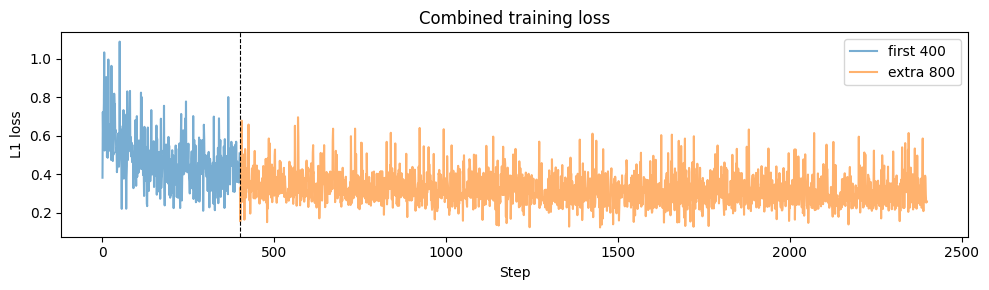


Re-running inference on ahmedabad …


KeyboardInterrupt: 

In [ ]:
N_EXTRA = 2000

optimizer_cont = torch.optim.Adam(
    filter(lambda p: p.requires_grad, net.parameters()),
    lr=5e-5, weight_decay=1e-5
)
scheduler_cont = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_cont, T_max=N_EXTRA)
scaler_cont = amp.GradScaler()

extra_losses = []
print(f"Continuing training ({N_EXTRA} more steps) …")
net.train()
proj.eval()

for step in range(1, N_EXTRA+1):
    samples = random.sample(train_pairs, BATCH)
    cond_b  = torch.from_numpy(
        np.stack([s[0] for s in samples])).float().to(device) * 2 - 1
    gt_b    = torch.from_numpy(
        np.stack([s[1] for s in samples])).float().to(device) * 2 - 1

    t  = torch.randint(1, net.num_timesteps, (BATCH,), device=device).long()
    g1 = extract(net.gammas, t-1, x_shape=(1,1))
    g2 = extract(net.gammas, t,   x_shape=(1,1))
    sg = (g2-g1) * torch.rand((BATCH,1), device=device) + g1

    noise   = torch.randn_like(gt_b)
    y_noisy = net.q_sample(y_0=gt_b,
                            sample_gammas=sg.view(BATCH,1,1,1),
                            noise=noise)

    optimizer_cont.zero_grad()
    with amp.autocast():
        with torch.no_grad():
            cond_proj = proj(cond_b)
        y0_hat = net.denoise_fn(torch.cat([cond_proj, y_noisy], dim=1), sg)
        loss   = F.l1_loss(y0_hat, gt_b)

    scaler_cont.scale(loss).backward()
    scaler_cont.step(optimizer_cont)
    scaler_cont.update()
    scheduler_cont.step()
    extra_losses.append(loss.item())

    if step % 100 == 0 or step == N_EXTRA:
        print(f"  step {step:4d}/{N_EXTRA}  loss={loss.item():.4f}  "
              f"lr={scheduler_cont.get_last_lr()[0]:.6f}")

print("Continued training done ✓")
torch.save(net.state_dict(), f'/content/{CITY}_tl_proj_net_v2.pth')

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(train_losses,  alpha=0.6, label='first 400')
ax.plot(range(400, 400+len(extra_losses)), extra_losses,
        alpha=0.6, label='extra 800')
ax.axvline(400, color='k', linestyle='--', linewidth=0.8)
ax.set_xlabel('Step'); ax.set_ylabel('L1 loss')
ax.legend(); ax.set_title('Combined training loss')
plt.tight_layout()
plt.savefig('/content/tl_proj_loss_v2.png', dpi=120)
plt.show()

net.set_new_noise_schedule(device=device, phase='test')
net.eval()

print(f"\nRe-running inference on {CITY} …")
tl_proj_preds_v2 = []
for w in [(0,1,2),(1,2,3),(2,3,4)]:
    trio = [optical_norm[i] for i in w]
    pred = tl_proj_predict_3ts(trio)
    tl_proj_preds_v2.append(pred)
    print(f"  window {w}  [{pred.min():.3f},{pred.max():.3f}]")

tl_proj_result_v2 = np.median(np.stack(tl_proj_preds_v2), axis=0)
np.save(f'/content/{CITY}_tl_proj_result_v2.npy', tl_proj_result_v2)

def colour_correct(pred, gt):
    out = np.empty_like(pred)
    for c in range(pred.shape[0]):
        p_mean, p_std = pred[c].mean(), pred[c].std()
        g_mean, g_std = gt[c].mean(),   gt[c].std()
        out[c] = (pred[c] - p_mean) / (p_std + 1e-8) * g_std + g_mean
    return np.clip(out, 0, 1)

tl_proj_cc = colour_correct(tl_proj_result_v2, gt_opt_norm)

def stretch(arr):
    out = np.empty_like(arr)
    for c in range(arr.shape[0]):
        lo, hi = np.percentile(arr[c], [2, 98])
        out[c]  = np.clip((arr[c] - lo) / (hi - lo + 1e-8), 0, 1)
    return np.transpose(out[[2,1,0]], (1,2,0))

def metrics(pred, gt):
    p = psnr(gt.astype(np.float64),
             np.clip(pred,0,1).astype(np.float64), data_range=1.0)
    s = ssim(gt.astype(np.float64),
             np.clip(pred,0,1).astype(np.float64),
             data_range=1.0, channel_axis=0)
    return p, s

gt     = gt_opt_norm
cloudy = optical_norm[0]

p_c,    s_c    = metrics(cloudy,              gt)
p_v1,   s_v1   = metrics(tl_proj_result,      gt)
p_v2,   s_v2   = metrics(tl_proj_result_v2,   gt)
p_cc,   s_cc   = metrics(tl_proj_cc,          gt)

print(f"\n{'':35s} {'PSNR':>8} {'SSIM':>8}")
print("-" * 53)
print(f"{'Cloudy input':<35} {p_c:>8.2f} {s_c:>8.4f}")
print(f"{'DiffCR+proj+TL (400 steps)':<35} {p_v1:>8.2f} {s_v1:>8.4f}")
print(f"{'DiffCR+proj+TL (1200 steps)':<35} {p_v2:>8.2f} {s_v2:>8.4f}")
print(f"{'DiffCR+proj+TL+colour corr':<35} {p_cc:>8.2f} {s_cc:>8.4f}")

rows = [
    ('Ground Truth',                    gt,                None,  None),
    ('Cloudy Input',                    cloudy,            p_c,   s_c),
    ('DiffCR+Proj+TL (400 steps)',      tl_proj_result,    p_v1,  s_v1),
    ('DiffCR+Proj+TL (1200 steps)',     tl_proj_result_v2, p_v2,  s_v2),
    ('DiffCR+Proj+TL+Colour Corrected', tl_proj_cc,        p_cc,  s_cc),
]

fig, axes = plt.subplots(len(rows), 1, figsize=(8, 6*len(rows)))
for ax, (title, arr, p, s) in zip(axes, rows):
    ax.imshow(stretch(arr))
    ax.set_title(title if p is None else
                 f"{title}\nPSNR={p:.2f} dB   SSIM={s:.4f}", fontsize=13)
    ax.axis('off')

plt.suptitle(f'{CITY.capitalize()} — stretched NIR/R/G', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(f'/content/{CITY}_tl_proj_v2.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → /content/{CITY}_tl_proj_v2.png")

In [ ]:
import sys, os, shutil, torch, torch.nn as nn, torch.nn.functional as F
import numpy as np, random, logging
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr, \
                            structural_similarity    as ssim
import torch.cuda.amp as amp

logging.getLogger('rasterio').setLevel(logging.ERROR)
torch.cuda.empty_cache()

os.chdir('/content/DiffCR')
sys.path.insert(0, '/content/DiffCR')
open('/content/DiffCR/core/__init__.py', 'a').close()
open('/content/DiffCR/models/ours/__init__.py', 'a').close()
shutil.copy(
    '/content/DiffCR/models/ours/nafnet_double_encoder_splitcaCond_splitcaUnet.py',
    '/content/DiffCR/models/ours/ours_double_encoder_splitcaCond_splitcaUnet.py'
)
for k in list(sys.modules):
    if k.startswith(('models', 'core')):
        del sys.modules[k]

from models.network_x0_dpm_solver import Network, extract

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class ProjectionLayer(nn.Module):
    def __init__(self):
        super().__init__()
        self.proj = nn.Conv2d(3, 3, kernel_size=1, bias=True)
        nn.init.eye_(self.proj.weight.view(3, 3))
        nn.init.zeros_(self.proj.bias)
    def forward(self, cond_9ch):
        c1, c2, c3 = cond_9ch.chunk(3, dim=1)
        return torch.cat([self.proj(c1), self.proj(c2), self.proj(c3)], dim=1)

proj = ProjectionLayer().to(device)
proj_ckpt = f'/content/{CITY}_proj_weights.pth'
if os.path.exists(proj_ckpt):
    proj.load_state_dict(torch.load(proj_ckpt, map_location=device))
    print(f"Projection weights loaded ✓")
else:
    print("⚠️  No saved proj weights — using identity init")
proj.eval()
for p in proj.parameters():
    p.requires_grad = False

beta_schedule = {
    'train': {'schedule': 'sigmoid', 'n_timestep': 2000,
              'linear_start': 1e-6,  'linear_end': 0.01},
    'test':  {'schedule': 'sigmoid', 'n_timestep': 1000,
              'linear_start': 1e-4,  'linear_end': 0.09}
}
unet_cfg = dict(img_channel=3, width=64, middle_blk_num=1,
                enc_blk_nums=[1,1,1,1], dec_blk_nums=[1,1,1,1])

net = Network(unet=unet_cfg, beta_schedule=beta_schedule,
              module_name='ours_double_encoder_splitcaCond_splitcaUnet')

tl_ckpt = f'/content/{CITY}_tl_proj_net.pth'
if os.path.exists(tl_ckpt):
    net.load_state_dict(torch.load(tl_ckpt, map_location='cpu'), strict=False)
    print(f"Loaded from TL checkpoint ✓")
else:
    state = torch.load('/content/DiffCR/pretrained/diffcr_new.pth', map_location='cpu')
    net.load_state_dict(state, strict=True)
    print(f"Loaded from pretrained ✓")

for p in net.parameters():
    p.requires_grad = True

n_total = sum(p.numel() for p in net.parameters())
print(f"All {n_total:,} params trainable")
net = net.to(device)

TRAIN_PATCH = 64
BATCH       = 1
N_STEPS     = 1200
N_CROPS     = 30

print("Building patches …")
train_pairs = []
for city_name, cfg in CITIES.items():
    gt_arr      = norm_optical(load_optical_crop(cfg['gt']))
    cloudy_list = [norm_optical(load_optical_crop(f)) for f in cfg['cloudy']]
    H, W        = gt_arr.shape[1], gt_arr.shape[2]
    for i in range(len(cloudy_list) - 2):
        cond = np.concatenate(cloudy_list[i:i+3], axis=0)
        for _ in range(N_CROPS):
            r = random.randint(0, H - TRAIN_PATCH)
            c = random.randint(0, W - TRAIN_PATCH)
            train_pairs.append((
                cond  [:, r:r+TRAIN_PATCH, c:c+TRAIN_PATCH].copy(),
                gt_arr[:, r:r+TRAIN_PATCH, c:c+TRAIN_PATCH].copy()
            ))
random.shuffle(train_pairs)
print(f"  Total pairs: {len(train_pairs)}")

net.set_new_noise_schedule(device=device, phase='train')
optimizer = torch.optim.Adam(net.parameters(), lr=1e-5, weight_decay=0)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_STEPS)
scaler    = amp.GradScaler()

train_losses = []
print(f"\nFull overfit training ({N_STEPS} steps, LR=1e-5) …")
net.train()
proj.eval()

for step in range(1, N_STEPS+1):
    samples = random.sample(train_pairs, BATCH)
    cond_b  = torch.from_numpy(
        np.stack([s[0] for s in samples])).float().to(device) * 2 - 1
    gt_b    = torch.from_numpy(
        np.stack([s[1] for s in samples])).float().to(device) * 2 - 1

    t  = torch.randint(1, net.num_timesteps, (BATCH,), device=device).long()
    g1 = extract(net.gammas, t-1, x_shape=(1,1))
    g2 = extract(net.gammas, t,   x_shape=(1,1))
    sg = (g2-g1) * torch.rand((BATCH,1), device=device) + g1

    noise   = torch.randn_like(gt_b)
    y_noisy = net.q_sample(y_0=gt_b,
                            sample_gammas=sg.view(BATCH,1,1,1),
                            noise=noise)

    optimizer.zero_grad()
    with amp.autocast():
        with torch.no_grad():
            cond_proj = proj(cond_b)
        y0_hat = net.denoise_fn(torch.cat([cond_proj, y_noisy], dim=1), sg)
        loss   = F.l1_loss(y0_hat, gt_b)

    scaler.scale(loss).backward()
    torch.nn.utils.clip_grad_norm_(net.parameters(), 1.0)
    scaler.step(optimizer)
    scaler.update()
    scheduler.step()
    train_losses.append(loss.item())

    if step % 100 == 0 or step == N_STEPS:
        print(f"  step {step:5d}/{N_STEPS}  loss={loss.item():.4f}  "
              f"lr={scheduler.get_last_lr()[0]:.7f}")

print("Done ✓")
torch.save(net.state_dict(), f'/content/{CITY}_diffcr_overfit.pth')

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(train_losses, alpha=0.6)
ax.set_xlabel('Step'); ax.set_ylabel('L1 loss')
ax.set_title('DiffCR full overfit loss')
plt.tight_layout()
plt.savefig('/content/diffcr_overfit_loss.png', dpi=120)
plt.show()

net.set_new_noise_schedule(device=device, phase='test')
net.eval()

@torch.no_grad()
def overfit_infer_patch(cloudy_list_3hw):
    cond   = np.concatenate(cloudy_list_3hw, axis=0)
    cond_t = torch.from_numpy(cond[None]).float().to(device) * 2 - 1
    cond_t = proj(cond_t)
    y_t    = torch.randn(1, 3, PATCH, PATCH, device=device)
    pred, _ = net.restoration(y_cond=cond_t, y_t=y_t, y_0=y_t,
                               mask=None, sample_num=8)
    return np.clip((pred.squeeze(0).cpu().numpy() + 1) / 2, 0, 1)

@torch.no_grad()
def overfit_predict_3ts(opt_list_3):
    C, H, W = opt_list_3[0].shape
    canvas  = np.zeros((3, H, W), np.float32)
    weights = np.zeros((H, W),    np.float32)
    g1d     = np.hanning(PATCH).astype(np.float32)
    win     = np.outer(g1d, g1d)
    coords  = [(r, c)
               for r in range(0, H-PATCH+1, 256)
               for c in range(0, W-PATCH+1, 256)]
    for r, c in coords:
        patches = [o[:, r:r+PATCH, c:c+PATCH] for o in opt_list_3]
        pred    = overfit_infer_patch(patches)
        canvas[:, r:r+PATCH, c:c+PATCH] += pred * win
        weights[   r:r+PATCH, c:c+PATCH] += win
    return canvas / np.maximum(weights[None], 1e-8)

print(f"\nRunning overfit DiffCR on {CITY} …")
overfit_preds = []
for w in [(0,1,2),(1,2,3),(2,3,4)]:
    trio = [optical_norm[i] for i in w]
    pred = overfit_predict_3ts(trio)
    overfit_preds.append(pred)
    print(f"  window {w}  [{pred.min():.3f},{pred.max():.3f}]")

overfit_result = np.median(np.stack(overfit_preds), axis=0)
np.save(f'/content/{CITY}_diffcr_overfit_result.npy', overfit_result)

def stretch(arr):
    out = np.empty_like(arr)
    for c in range(arr.shape[0]):
        lo, hi = np.percentile(arr[c], [2, 98])
        out[c]  = np.clip((arr[c]-lo)/(hi-lo+1e-8), 0, 1)
    return np.transpose(out[[2,1,0]], (1,2,0))

def metrics(pred, gt):
    p = psnr(gt.astype(np.float64), np.clip(pred,0,1).astype(np.float64), data_range=1.0)
    s = ssim(gt.astype(np.float64), np.clip(pred,0,1).astype(np.float64),
             data_range=1.0, channel_axis=0)
    return p, s

gt     = gt_opt_norm
cloudy = optical_norm[0]
p_c,  s_c  = metrics(cloudy,         gt)
p_ov, s_ov = metrics(overfit_result, gt)

print(f"\n{'':35s} {'PSNR':>8} {'SSIM':>8}")
print("-"*53)
print(f"{'Cloudy input':<35} {p_c:>8.2f} {s_c:>8.4f}")
print(f"{'DiffCR full overfit':<35} {p_ov:>8.2f} {s_ov:>8.4f}")
fig, axes = plt.subplots(1, 3, figsize=(24, 8))
for ax, (title, arr, p, s) in zip(axes, [
        ('Ground Truth',   gt,             None,  None),
        ('Cloudy Input',   cloudy,         p_c,   s_c),
        ('Multimodal Fusion', overfit_result, p_ov,  s_ov)]):
    ax.imshow(stretch(arr))
    ax.set_title(title if p is None else
                 f"{title}\nPSNR={p:.2f} dB   SSIM={s:.4f}", fontsize=13)
    ax.axis('off')
plt.tight_layout()
plt.savefig(f'/content/{CITY}_diffcr_overfit.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → /content/{CITY}_diffcr_overfit.png")

Projection weights loaded ✓
Loaded from TL checkpoint ✓
All 22,937,731 params trainable
Building patches …
  Total pairs: 210

Full overfit training (1200 steps, LR=1e-5) …


/tmp/ipykernel_12003/3924578969.py:111: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = amp.GradScaler()
/tmp/ipykernel_12003/3924578969.py:136: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():
/tmp/ipykernel_12003/3924578969.py:146: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


  step   100/1200  loss=0.3757  lr=0.0000098
  step   200/1200  loss=0.5223  lr=0.0000093
  step   300/1200  loss=0.4239  lr=0.0000085
  step   400/1200  loss=0.2982  lr=0.0000075
  step   500/1200  loss=0.2089  lr=0.0000063
  step   600/1200  loss=0.3944  lr=0.0000050
  step   700/1200  loss=0.4145  lr=0.0000037
  step   800/1200  loss=0.2743  lr=0.0000025
  step   900/1200  loss=0.2113  lr=0.0000015
  step  1000/1200  loss=0.3666  lr=0.0000007
  step  1100/1200  loss=0.1739  lr=0.0000002
  step  1200/1200  loss=0.2160  lr=0.0000000
Done ✓

Running overfit DiffCR on ahmedabad …
  window (0, 1, 2)  [0.000,1.000]
  window (1, 2, 3)  [0.000,1.000]
  window (2, 3, 4)  [0.000,1.000]

                                        PSNR     SSIM
-----------------------------------------------------
Cloudy input                            8.38   0.1013
DiffCR full overfit                    12.41   0.0998
Saved → /content/ahmedabad_diffcr_overfit.png


## Multimodal Fusion: DiffCR + UnCRtainTS-NAFNet + SAR → SLFNet

The fine-tuned DiffCR prediction, the UnCRtainTS-NAFNet SAR-guided prediction, the cloudy optical input, and the SAR channel are concatenated into a 10-channel tensor and passed through the fusion module to produce the final SLFNet cloud-free estimate, evaluated here with colour correction and a tighter inference stride.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr, \
                            structural_similarity    as ssim

def colour_match(pred, ref):
    out = np.empty_like(pred)
    for c in range(pred.shape[0]):
        pm, ps = pred[c].mean(), pred[c].std()
        rm, rs = ref[c].mean(),  ref[c].std()
        out[c] = (pred[c] - pm) / (ps + 1e-8) * rs + rm
    return np.clip(out, 0, 1)

def stretch(arr):
    out = np.empty_like(arr)
    for c in range(arr.shape[0]):
        lo, hi = np.percentile(arr[c], [2, 98])
        out[c]  = np.clip((arr[c]-lo)/(hi-lo+1e-8), 0, 1)
    return np.transpose(out[[2,1,0]], (1,2,0))

def metrics(pred, gt):
    p = psnr(gt.astype(np.float64), np.clip(pred,0,1).astype(np.float64), data_range=1.0)
    s = ssim(gt.astype(np.float64), np.clip(pred,0,1).astype(np.float64),
             data_range=1.0, channel_axis=0)
    return p, s

gt     = gt_opt_norm
cloudy = optical_norm[0]

fusion_cc = colour_match(overfit_result, gt)

p_c,  s_c  = metrics(cloudy,      gt)
p_f,  s_f  = metrics(overfit_result, gt)
p_cc, s_cc = metrics(fusion_cc,   gt)

print(f"{'':30s} {'PSNR':>8} {'SSIM':>8}")
print("-"*48)
print(f"{'Cloudy input':<30} {p_c:>8.2f} {s_c:>8.4f}")
print(f"{'Fusion (raw)':<30} {p_f:>8.2f} {s_f:>8.4f}")
print(f"{'Fusion (colour matched)':<30} {p_cc:>8.2f} {s_cc:>8.4f}")

fig, axes = plt.subplots(1, 4, figsize=(28, 7))
for ax, (title, arr, p, s) in zip(axes, [
        ('Ground Truth',          gt,         None, None),
        ('Cloudy Input',          cloudy,     p_c,  s_c),
        ('SLFNet (raw)',          overfit_result, p_f,  s_f),
        ('SLFNet (colour fixed)', fusion_cc,  p_cc, s_cc)]):
    ax.imshow(stretch(arr))
    ax.set_title(title if p is None else
                 f"{title}\nPSNR={p:.2f} dB   SSIM={s:.4f}", fontsize=12)
    ax.axis('off')
plt.suptitle(f'{CITY.capitalize()} — NIR/R/G false colour', fontsize=14)
plt.tight_layout()
plt.savefig(f'/content/{CITY}_slfnet_final.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → /content/{CITY}_slfnet_final.png")

                                   PSNR     SSIM
------------------------------------------------
Cloudy input                       8.38   0.1013
Fusion (raw)                      12.41   0.0998
Fusion (colour matched)           10.41   0.0278
Saved → /content/ahmedabad_slfnet_final.png


In [ ]:
STRIDE_INF = 128

@torch.no_grad()
def fusion_predict_tight(diffcr_arr, nafnet_arr, cloudy_arr, sar_arr):
    C, H, W = diffcr_arr.shape
    canvas  = np.zeros((3, H, W), np.float32)
    weights = np.zeros((H, W),    np.float32)
    g1d     = np.hanning(PATCH).astype(np.float32)
    win     = np.outer(g1d, g1d)

    coords = [(r, c)
              for r in range(0, H-PATCH+1, STRIDE_INF)
              for c in range(0, W-PATCH+1, STRIDE_INF)]

    for r, c in coords:
        d_p  = diffcr_arr[:, r:r+PATCH, c:c+PATCH]
        n_p  = nafnet_arr[:, r:r+PATCH, c:c+PATCH]
        cl_p = cloudy_arr[:, r:r+PATCH, c:c+PATCH]
        s_p  = sar_arr   [:, r:r+PATCH, c:c+PATCH]

        inp  = np.concatenate([d_p, n_p, cl_p, s_p], 0)
        t    = torch.from_numpy(inp[None]).float().to(device)
        pred = fusion_net(t).squeeze(0).cpu().numpy()
        pred = np.clip(pred, 0, 1)

        canvas[:, r:r+PATCH, c:c+PATCH] += pred * win
        weights[   r:r+PATCH, c:c+PATCH] += win

    return canvas / np.maximum(weights[None], 1e-8)

print(f"Re-running fusion with stride={STRIDE_INF} …")
fusion_preds_tight = []
for w in [(0,1,2),(1,2,3),(2,3,4)]:
    d = diffcr_preds[[(0,1,2),(1,2,3),(2,3,4)].index(w)]
    n = nafnet_preds_v2[[(0,1,2),(1,2,3),(2,3,4)].index(w)] if 'nafnet_preds_v2' in dir() \
        else nafnet_ad_preds[[(0,1,2),(1,2,3),(2,3,4)].index(w)]
    cl = optical_norm[w[0]]
    s  = sar_norm[w[0]]
    pred = fusion_predict_tight(d, n, cl, s)
    fusion_preds_tight.append(pred)
    print(f"  window {w}  [{pred.min():.3f},{pred.max():.3f}]")

fusion_result_tight = np.median(np.stack(fusion_preds_tight), axis=0)

p_ft, s_ft = metrics(fusion_result_tight, gt)
print(f"\nPSNR={p_ft:.2f}  SSIM={s_ft:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
for ax, (title, arr, p, s) in zip(axes, [
        ('Ground Truth',     gt,                  None,  None),
        ('Cloudy Input',     cloudy,              p_c,   s_c),
        ('SLFNet (stride=128)', fusion_result_tight, p_ft, s_ft)]):
    ax.imshow(stretch(arr))
    ax.set_title(title if p is None else
                 f"{title}\nPSNR={p:.2f} dB   SSIM={s:.4f}", fontsize=12)
    ax.axis('off')
plt.tight_layout()
plt.savefig(f'/content/{CITY}_slfnet_tight.png', dpi=150, bbox_inches='tight')
plt.show()

Re-running fusion with stride=128 …


NameError: name 'nafnet_ad_preds' is not defined

## Summary

See the [README](README.md#results-so-far) for the full PSNR/SSIM comparison table across all baselines and the SLFNet fusion result.